In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

import zipfile, os

zip_path = '/content/drive/MyDrive/bird_CUB_200_2011.zip'  # adjust
extract_path = '/content/cub_birds'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_path)

data_root = os.path.join(extract_path, 'CUB_200_2011')


In [3]:
os.listdir(extract_path)

['CUB_200_2011']

In [4]:
import pandas as pd
import os

base_path = data_root

# Load official files
images = pd.read_csv(os.path.join(base_path, "images.txt"),
                     sep=" ", names=["image_id", "image_name"])

labels = pd.read_csv(os.path.join(base_path, "image_class_labels.txt"),
                     sep=" ", names=["image_id", "class_id"])

splits = pd.read_csv(os.path.join(base_path, "train_test_split.txt"),
                     sep=" ", names=["image_id", "is_train"])

bboxes = pd.read_csv(os.path.join(base_path, "bounding_boxes.txt"),
                     sep=" ", names=["image_id", "x", "y", "w", "h"])

# Merge everything
df = images.merge(labels, on="image_id")
df = df.merge(splits, on="image_id")
df = df.merge(bboxes, on="image_id")

# Add full filepath
df["filepath"] = df["image_name"].apply(
    lambda x: os.path.join(base_path, "images", x)
)

print("Total samples:", len(df))
print("Unique classes:", df["class_id"].nunique())

Total samples: 11788
Unique classes: 200


In [5]:
df["label"] = df["class_id"] - 1

print("Min label:", df["label"].min())
print("Max label:", df["label"].max())

Min label: 0
Max label: 199


In [6]:
train_full_df = df[df["is_train"] == 1].copy()
test_df = df[df["is_train"] == 0].copy()

print("Train size:", len(train_full_df))
print("Test size:", len(test_df))

print("Train unique classes:", train_full_df["label"].nunique())
print("Test unique classes:", test_df["label"].nunique())

Train size: 5994
Test size: 5794
Train unique classes: 200
Test unique classes: 200


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.1,
    stratify=train_full_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

print("Train classes:", train_df["label"].nunique())
print("Val classes:", val_df["label"].nunique())

Train size: 5394
Val size: 600
Train classes: 200
Val classes: 200


In [8]:
train_counts = train_df["label"].value_counts()
val_counts = val_df["label"].value_counts()

print("Train min samples per class:", train_counts.min())
print("Val min samples per class:", val_counts.min())

Train min samples per class: 26
Val min samples per class: 3


#  Efficent Net Model(B4) - 1.1


In [9]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os

IMG_SIZE = 380
BATCH_SIZE = 24   # Increase to 24/32 if GPU allows
NUM_CLASSES = 200
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [10]:
def preprocess_image(row):
    image = tf.io.read_file(row["filepath"])
    image = tf.image.decode_jpeg(image, channels=3)

    image_shape = tf.shape(image)
    image_height = tf.cast(image_shape[0], tf.float32)
    image_width = tf.cast(image_shape[1], tf.float32)

    # Get bounding box coordinates from DataFrame row
    x = tf.cast(row["x"], tf.float32)
    y = tf.cast(row["y"], tf.float32)
    w = tf.cast(row["w"], tf.float32)
    h = tf.cast(row["h"], tf.float32)

    # Calculate normalized bounding box coordinates [y1, x1, y2, x2]
    # tf.image.crop_and_resize clips boxes that are out of bounds automatically.
    y1 = y / image_height
    x1 = x / image_width
    y2 = (y + h) / image_height
    x2 = (x + w) / image_width

    boxes = tf.expand_dims([y1, x1, y2, x2], axis=0)
    box_indices = tf.constant([0], dtype=tf.int32)
    crop_size = tf.constant([IMG_SIZE, IMG_SIZE], dtype=tf.int32)

    # Crop and resize the image directly
    image = tf.image.crop_and_resize(
        tf.expand_dims(image, axis=0), # Add batch dimension for crop_and_resize
        boxes,
        box_indices,
        crop_size
    )
    image = tf.squeeze(image, axis=0) # Remove batch dimension

    # EfficientNet preprocessing
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    label = tf.cast(row["label"], tf.int32)

    return image, label

In [11]:
def build_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices(dict(dataframe))

    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(2048, seed=SEED)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = build_dataset(train_df, training=True)
val_ds   = build_dataset(val_df)
test_ds  = build_dataset(test_df)

In [12]:
base_model = tf.keras.applications.EfficientNetB4(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomRotation(0.08),
    layers.GaussianNoise(0.03),
])

In [14]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [15]:
EPOCHS_PHASE1 = 8

steps_per_epoch = len(train_df) // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS_PHASE1

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

In [16]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "efficientnetb4_phase1.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [18]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks
)

Epoch 1/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1666 - loss: 4.5588

225/225 ━━━━━━━━━━━━━━━━━━━━ 56s 131ms/step - accuracy: 0.1672 - loss: 4.5531 - val_accuracy: 0.6800 - val_loss: 1.8144
Epoch 2/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6280 - loss: 1.3987

225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.6281 - loss: 1.3985 - val_accuracy: 0.7300 - val_loss: 0.9499
Epoch 3/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7235 - loss: 0.9479

225/225 ━━━━━━━━━━━━━━━━━━━━ 24s 101ms/step - accuracy: 0.7235 - loss: 0.9479 - val_accuracy: 0.7633 - val_loss: 0.8671
Epoch 4/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.7881 - loss: 0.7612 - val_accuracy: 0.7517 - val_loss: 0.8373
Epoch 5/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.8250 - loss: 0.6041 - val_accuracy: 0.7517 - val_loss: 0.8027
Epoch 6/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.8480 - loss: 0.5283 - val_accuracy: 0.7600 - val_loss: 0.7752


In [19]:
print(len(base_model.layers))

475


In [20]:
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       358,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,763,960 (71.58 MB)

 Trainable params: 362,184 (1.38 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

 Optimizer params: 724,369 (2.76 MB)

In [21]:
base_model.trainable = True

for layer in base_model.layers[:250]:
    layer.trainable = False

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [23]:
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 107s 226ms/step - accuracy: 0.5241 - loss: 1.9383 - val_accuracy: 0.7667 - val_loss: 0.7801
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.8082 - loss: 0.6757 - val_accuracy: 0.7967 - val_loss: 0.6997
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.8660 - loss: 0.4386 - val_accuracy: 0.8000 - val_loss: 0.6944
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.8958 - loss: 0.3471 - val_accuracy: 0.8300 - val_loss: 0.6389
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 46s 195ms/step - accuracy: 0.9203 - loss: 0.2678 - val_accuracy: 0.8317 - val_loss: 0.6347
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.9319 - loss: 0.2171 - val_accuracy: 0.8433 - val_loss: 0.6116
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 194ms/step - accuracy: 0.9589 - loss: 0.1477 - val_accuracy: 0.8350 - val_loss: 0.6415
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.9599 - loss: 

In [ ]:
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 103s 218ms/step - accuracy: 0.5630 - loss: 1.6916 - val_accuracy: 0.7883 - val_loss: 0.7444
Epoch 2/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 193ms/step - accuracy: 0.8190 - loss: 0.5825 - val_accuracy: 0.8083 - val_loss: 0.6586
Epoch 3/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 193ms/step - accuracy: 0.8927 - loss: 0.3614 - val_accuracy: 0.8233 - val_loss: 0.6728
Epoch 4/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 192ms/step - accuracy: 0.9089 - loss: 0.2987 - val_accuracy: 0.8167 - val_loss: 0.6553
Epoch 5/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 193ms/step - accuracy: 0.9373 - loss: 0.2090 - val_accuracy: 0.8317 - val_loss: 0.6424
Epoch 6/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 192ms/step - accuracy: 0.9512 - loss: 0.1634 - val_accuracy: 0.8300 - val_loss: 0.6411
Epoch 7/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 193ms/step - accuracy: 0.9645 - loss: 0.1299 - val_accuracy: 0.8333 - val_loss: 0.6580
Epoch 8/15
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 192ms/step - accuracy: 0.9645 - loss: 

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Extract test images and labels from test_ds
test_images = []
true_labels = []

for images, labels in test_ds:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
true_labels = np.concatenate(true_labels)

# Evaluate model
loss, accuracy = model.evaluate(test_images, true_labels, batch_size=24, verbose=1)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Predictions
pred_probs = model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)

# 🔹 Overall Precision, Recall, F1
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

print("\nOverall Metrics:")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall:    {recall_macro:.4f}")
print(f"Macro F1-Score:  {f1_macro:.4f}")

print(f"\nWeighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1-Score:  {f1_weighted:.4f}")

# 🔹 Full Classification Report (per class)
print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_labels))

242/242 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.8403 - loss: 0.6347

Test Loss: 0.6162
Test Accuracy: 85.07%
182/182 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step

Overall Metrics:
Macro Precision: 0.8563
Macro Recall:    0.8519
Macro F1-Score:  0.8491

Weighted Precision: 0.8564
Weighted Recall:    0.8509
Weighted F1-Score:  0.8487

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        30
           1       1.00      0.63      0.78        30
           2       0.73      0.96      0.83        28
           3       1.00      1.00      1.00        30
           4       0.72      0.93      0.81        14
           5       0.91      0.91      0.91        11
           6       1.00      0.96      0.98        23
           7       0.89      0.89      0.89        18
           8       0.62      0.52      0.57        29
           9       1.00      0.93      0.97        30
          10       0.72      0.60     

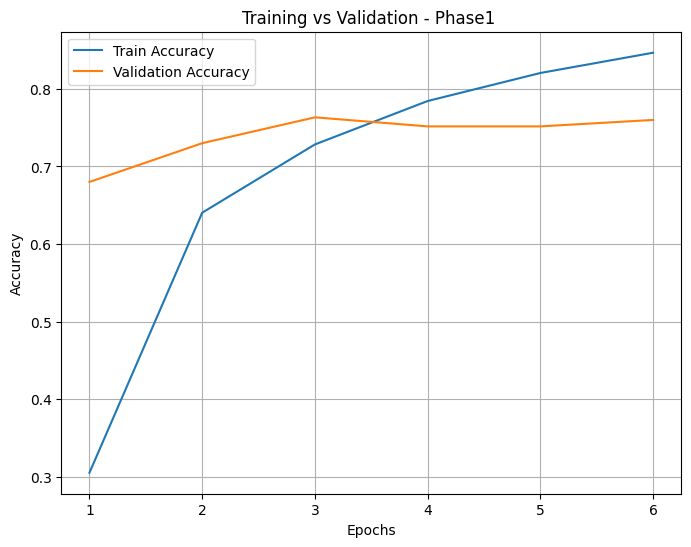

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Extract history
train_acc = history_phase1.history['accuracy']
val_acc = history_phase1.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')



plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation - Phase1 ")
plt.legend()
plt.grid(True)
plt.show()

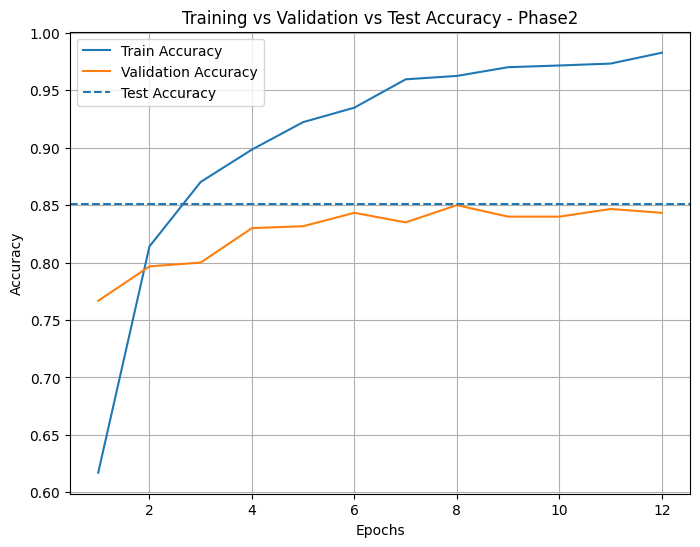

In [26]:
# Extract history
train_acc = history_phase2.history['accuracy']
val_acc = history_phase2.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

# Add test accuracy as horizontal line
plt.axhline(y=accuracy, linestyle='--', label='Test Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation vs Test Accuracy - Phase2")
plt.legend()
plt.grid(True)
plt.show()

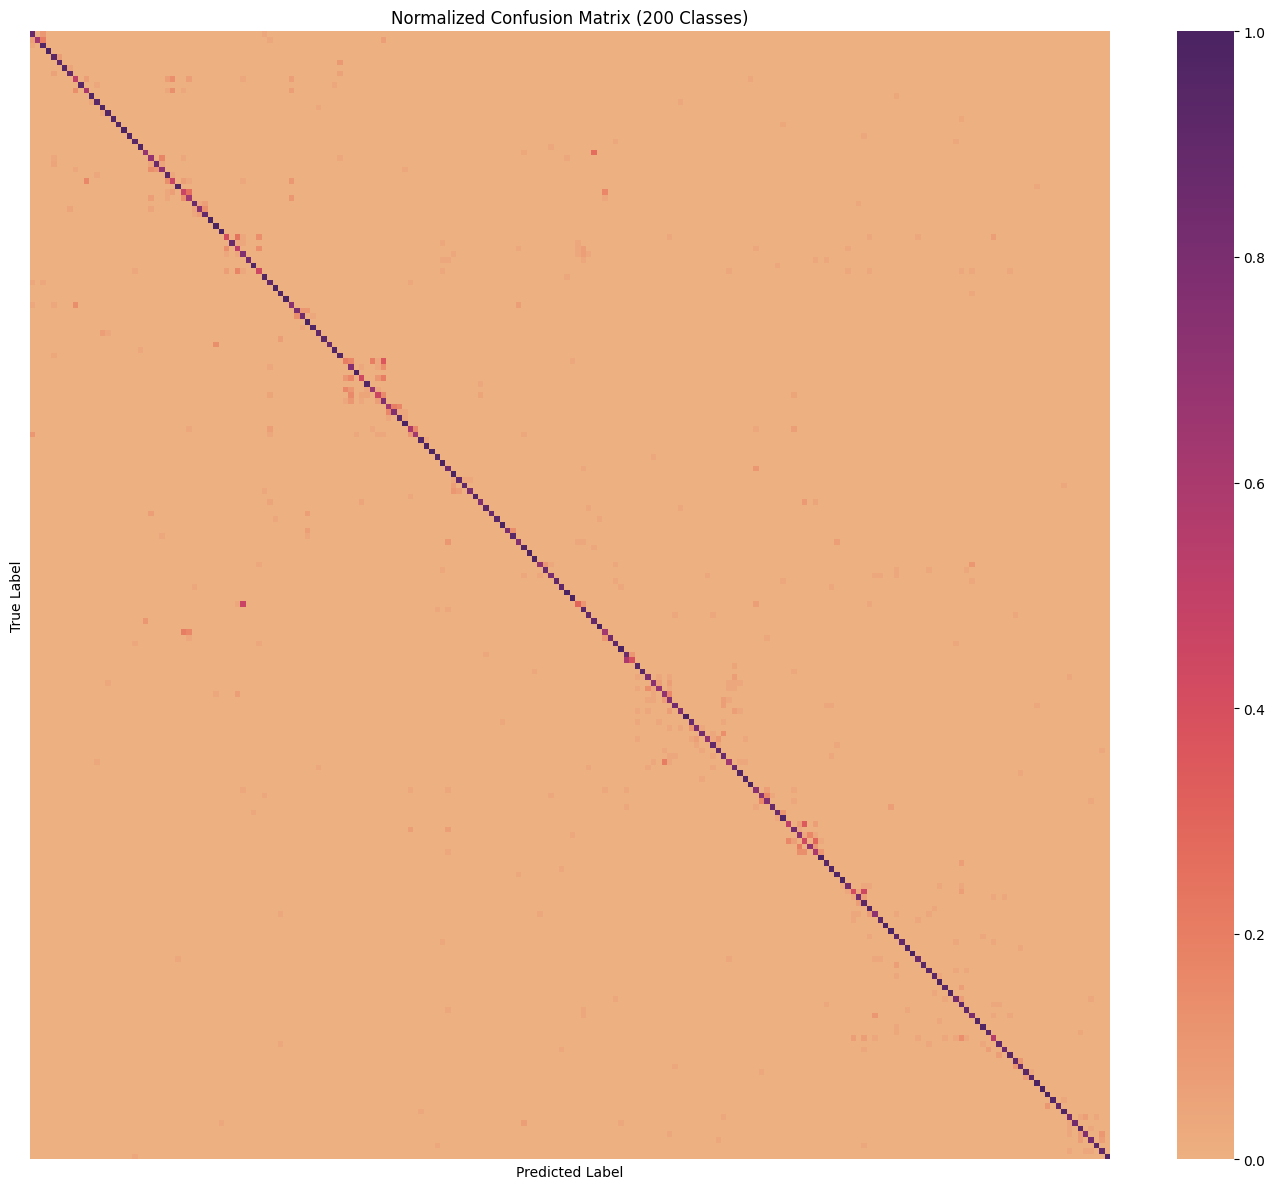

In [40]:
import seaborn as sns


# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Normalize by true class (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_normalized,
    cmap="flare",       # clean professional colormap
    cbar=True,
    xticklabels=False,    # too many labels to display
    yticklabels=False
)

plt.title("Normalized Confusion Matrix (200 Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [35]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 380, 380, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       358,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,720,825 (193.48 MB)

 Trainable params: 16,340,616 (62.33 MB)

 Non-trainable params: 1,698,975 (6.48 MB)

 Optimizer params: 32,681,234 (124.67 MB)

In [36]:
import os

project_path = "/content/drive/MyDrive/DL_Coursework_Project"
os.makedirs(project_path, exist_ok=True)

print("Saving to:", project_path)

Saving to: /content/drive/MyDrive/DL_Coursework_Project


In [37]:
model.save(f"{project_path}/final_efficientnet_b4.keras")

# Extract unique class names from the 'image_name' column in 'df'
# The 'image_name' column format is '001.Class_Name/image.jpg'
# We extract 'Class_Name' and ensure the list is ordered by class_id.
unique_classes_info = df[['class_id', 'image_name']].drop_duplicates(subset=['class_id'])
unique_classes_info['extracted_class_name'] = unique_classes_info['image_name'].apply(lambda x: x.split('/')[0][4:])
sorted_classes = unique_classes_info.sort_values(by='class_id')
class_names = sorted_classes['extracted_class_name'].tolist()

np.save(f"{project_path}/class_names.npy", class_names)




# Custom Cnn Model - 1.2



In [12]:
IMG_SIZE = 128


In [13]:
def preprocess_image_custom(row):
    image = tf.io.read_file(row["filepath"])
    image = tf.image.decode_jpeg(image, channels=3)

    image_shape = tf.shape(image)
    image_height = tf.cast(image_shape[0], tf.float32)
    image_width = tf.cast(image_shape[1], tf.float32)

    x = tf.cast(row["x"], tf.float32)
    y = tf.cast(row["y"], tf.float32)
    w = tf.cast(row["w"], tf.float32)
    h = tf.cast(row["h"], tf.float32)

    y1 = y / image_height
    x1 = x / image_width
    y2 = (y + h) / image_height
    x2 = (x + w) / image_width

    boxes = tf.expand_dims([y1, x1, y2, x2], axis=0)
    box_indices = tf.constant([0], dtype=tf.int32)

    image = tf.image.crop_and_resize(
        tf.expand_dims(image, axis=0),
        boxes,
        box_indices,
        [IMG_SIZE, IMG_SIZE]
    )




    image = tf.squeeze(image, axis=0)

    # Normalize ONCE
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.cast(row["label"], tf.int32)

    return image, label

In [14]:
data_augmentation_custom = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [15]:
def build_dataset_custom(dataframe, training=False):

    ds = tf.data.Dataset.from_tensor_slices(dict(dataframe))

    ds = ds.map(preprocess_image_custom,
                num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(2048, seed=SEED)

        ds = ds.map(
            lambda x, y: (
                tf.clip_by_value(
                    data_augmentation_custom(x, training=True),
                    0.0, 1.0
                ),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds_custom = build_dataset_custom(train_df, training=True)
val_ds_custom   = build_dataset_custom(val_df)
test_ds_custom  = build_dataset_custom(test_df)

In [16]:
for images, labels in train_ds_custom.take(1):
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())

Min pixel: 0.0
Max pixel: 1.0


In [17]:
import tensorflow as tf
from tensorflow.keras import layers

def conv_block(x, filters):

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Downsample
    x = layers.Conv2D(filters, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x


def build_custom_model(input_shape=(128,128,3), num_classes=200):

    inputs = tf.keras.Input(shape=input_shape)

    x = inputs

    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    return model


custom_model = build_custom_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

custom_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,195,720 (31.26 MB)

 Trainable params: 8,188,936 (31.24 MB)

 Non-trainable params: 6,784 (26.50 KB)

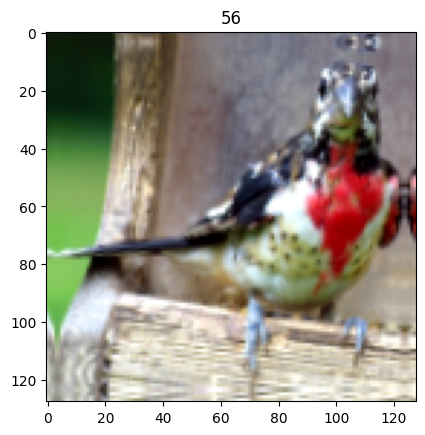

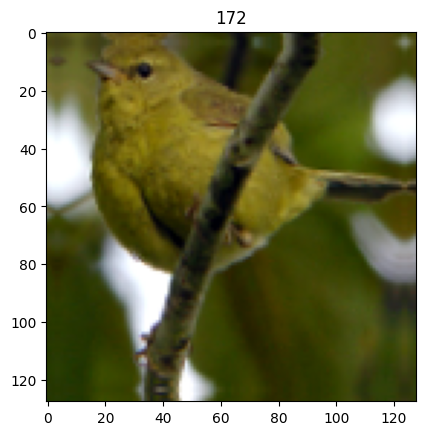

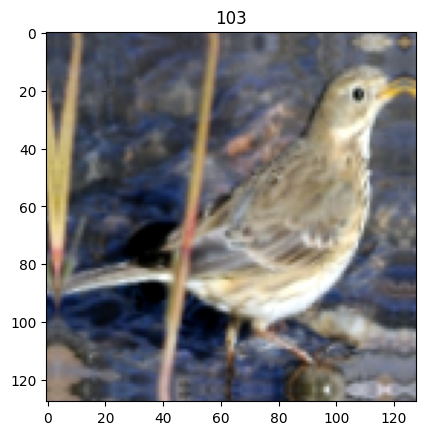

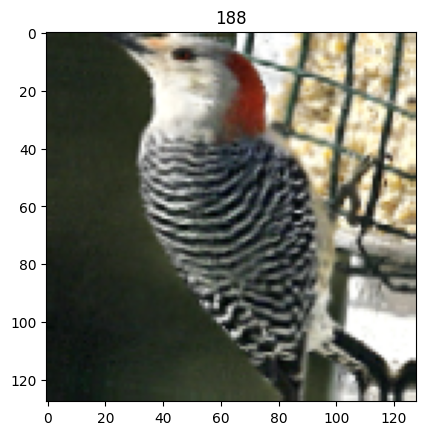

In [47]:
import matplotlib.pyplot as plt

for images, labels in train_ds_custom.take(1):
    for i in range(4):
        plt.imshow(images[i].numpy())
        plt.title(labels[i].numpy())
        plt.show()

In [18]:
EPOCHS = 30
steps_per_epoch = tf.data.experimental.cardinality(train_ds_custom).numpy()

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=EPOCHS * steps_per_epoch
)


optimizer = tf.keras.optimizers.Adam(lr_schedule)

In [19]:
custom_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )
]

In [21]:
history_custom = custom_model.fit(
    train_ds_custom,
    validation_data=val_ds_custom,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 50s 109ms/step - accuracy: 0.0057 - loss: 5.7734 - val_accuracy: 0.0083 - val_loss: 5.5305
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0124 - loss: 5.3562 - val_accuracy: 0.0150 - val_loss: 5.2512
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0191 - loss: 5.1771 - val_accuracy: 0.0317 - val_loss: 4.8870
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0236 - loss: 4.9878 - val_accuracy: 0.0250 - val_loss: 6.2411
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0298 - loss: 4.8569 - val_accuracy: 0.0233 - val_loss: 5.7459
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0332 - loss: 4.7928 - val_accuracy: 0.0450 - val_loss: 4.6196
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.0377 - loss: 4.6225 - val_accuracy: 0.0533 - val_loss: 4.7403
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0442 - loss: 4.5204 - val_ac

In [ ]:
'''history_custom = custom_model.fit(
    train_ds_custom,
    validation_data=val_ds_custom,
    epochs=EPOCHS,
    callbacks=callbacks
)'''

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.0408 - loss: 4.6100 - val_accuracy: 0.0267 - val_loss: 7.5258
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0471 - loss: 4.4176 - val_accuracy: 0.0217 - val_loss: 9.1302
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0561 - loss: 4.3190 - val_accuracy: 0.0383 - val_loss: 5.0633
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0658 - loss: 4.2179 - val_accuracy: 0.0550 - val_loss: 4.5566
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0790 - loss: 4.1064 - val_accuracy: 0.0817 - val_loss: 4.1903
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0836 - loss: 4.0488 - val_accuracy: 0.0917 - val_loss: 4.1203
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0989 - loss: 3.9856 - val_accuracy: 0.0600 - val_loss: 4.8191
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1064 - loss: 3.8132 - val_acc

In [70]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Extract test images and labels from test_ds
test_images = []
true_labels = []

for images, labels in test_ds_custom:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
true_labels = np.concatenate(true_labels)

# Evaluate model
loss, accuracy = custom_model.evaluate(test_images, true_labels, batch_size=24, verbose=1)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Predictions
pred_probs = custom_model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)

# 🔹 Overall Precision, Recall, F1
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

print("\nOverall Metrics:")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall:    {recall_macro:.4f}")
print(f"Macro F1-Score:  {f1_macro:.4f}")

print(f"\nWeighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1-Score:  {f1_weighted:.4f}")

# 🔹 Full Classification Report (per class)
print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_labels))

242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2317 - loss: 3.2669

Test Loss: 3.2431
Test Accuracy: 22.92%
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

Overall Metrics:
Macro Precision: 0.2267
Macro Recall:    0.2297
Macro F1-Score:  0.2095

Weighted Precision: 0.2286
Weighted Recall:    0.2292
Weighted F1-Score:  0.2107

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.20      0.20        30
           1       0.07      0.03      0.05        30
           2       0.00      0.00      0.00        28
           3       0.22      0.17      0.19        30
           4       0.28      0.36      0.31        14
           5       0.06      0.36      0.11        11
           6       0.25      0.13      0.17        23
           7       0.08      0.17      0.11        18
           8       0.00      0.00      0.00        29
           9       0.74      0.67      0.70        30
          10       0.23      0.27      0.25

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
''''from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


# Extract test images and labels from test_ds
test_images = []
true_labels = []

for images, labels in test_ds_custom:
    test_images.append(images.numpy())
    true_labels.append(labels.numpy())

test_images = np.concatenate(test_images)
true_labels = np.concatenate(true_labels)

# Evaluate on test set (returns loss and metrics like accuracy)
loss, accuracy = custom_model.evaluate(test_images, true_labels, batch_size=24, verbose=1)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Get predictions for detailed metrics
pred_probs = custom_model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)


# Classification report (precision, recall, F1-score)
report = classification_report(true_labels, pred_labels)
print("Classification Report:")
print(report)'''

242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3303 - loss: 2.7501
Test Loss: 2.7441
Test Accuracy: 32.72%
182/182 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.30      0.30        30
           1       0.24      0.13      0.17        30
           2       0.12      0.14      0.13        28
           3       0.23      0.33      0.27        30
           4       0.38      0.64      0.47        14
           5       0.06      0.18      0.09        11
           6       0.33      0.48      0.39        23
           7       0.26      0.33      0.29        18
           8       0.00      0.00      0.00        29
           9       0.61      0.63      0.62        30
          10       0.40      0.20      0.27        30
          11       0.79      0.88      0.84        26
          12       0.27      0.47      0.34        30
          13       0.53      0.67      0.59        30
        

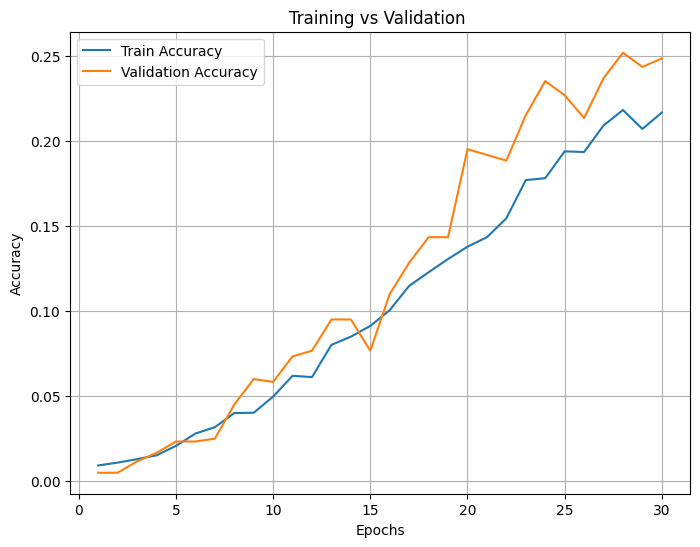

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Extract history
train_acc = history_custom.history['accuracy']
val_acc = history_custom.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')



plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation ")
plt.legend()
plt.grid(True)
plt.show()

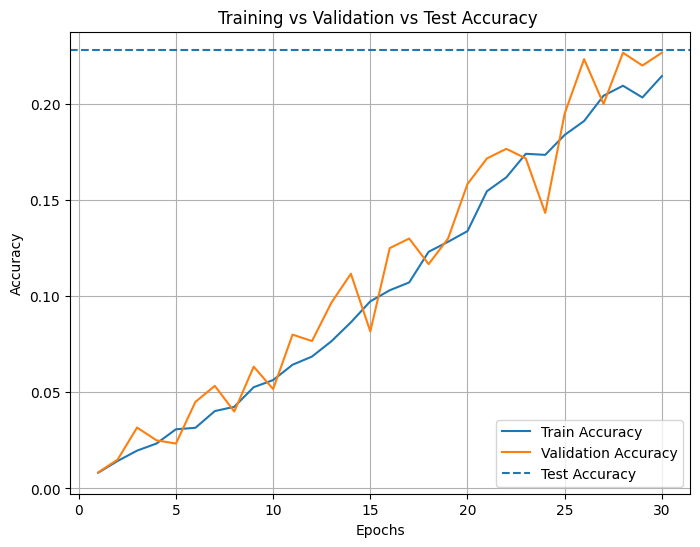

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Extract history
train_acc = history_custom.history['accuracy']
val_acc = history_custom.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

# Add test accuracy as horizontal line
plt.axhline(y=accuracy, linestyle='--', label='Test Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation vs Test Accuracy ")
plt.legend()
plt.grid(True)
plt.show()

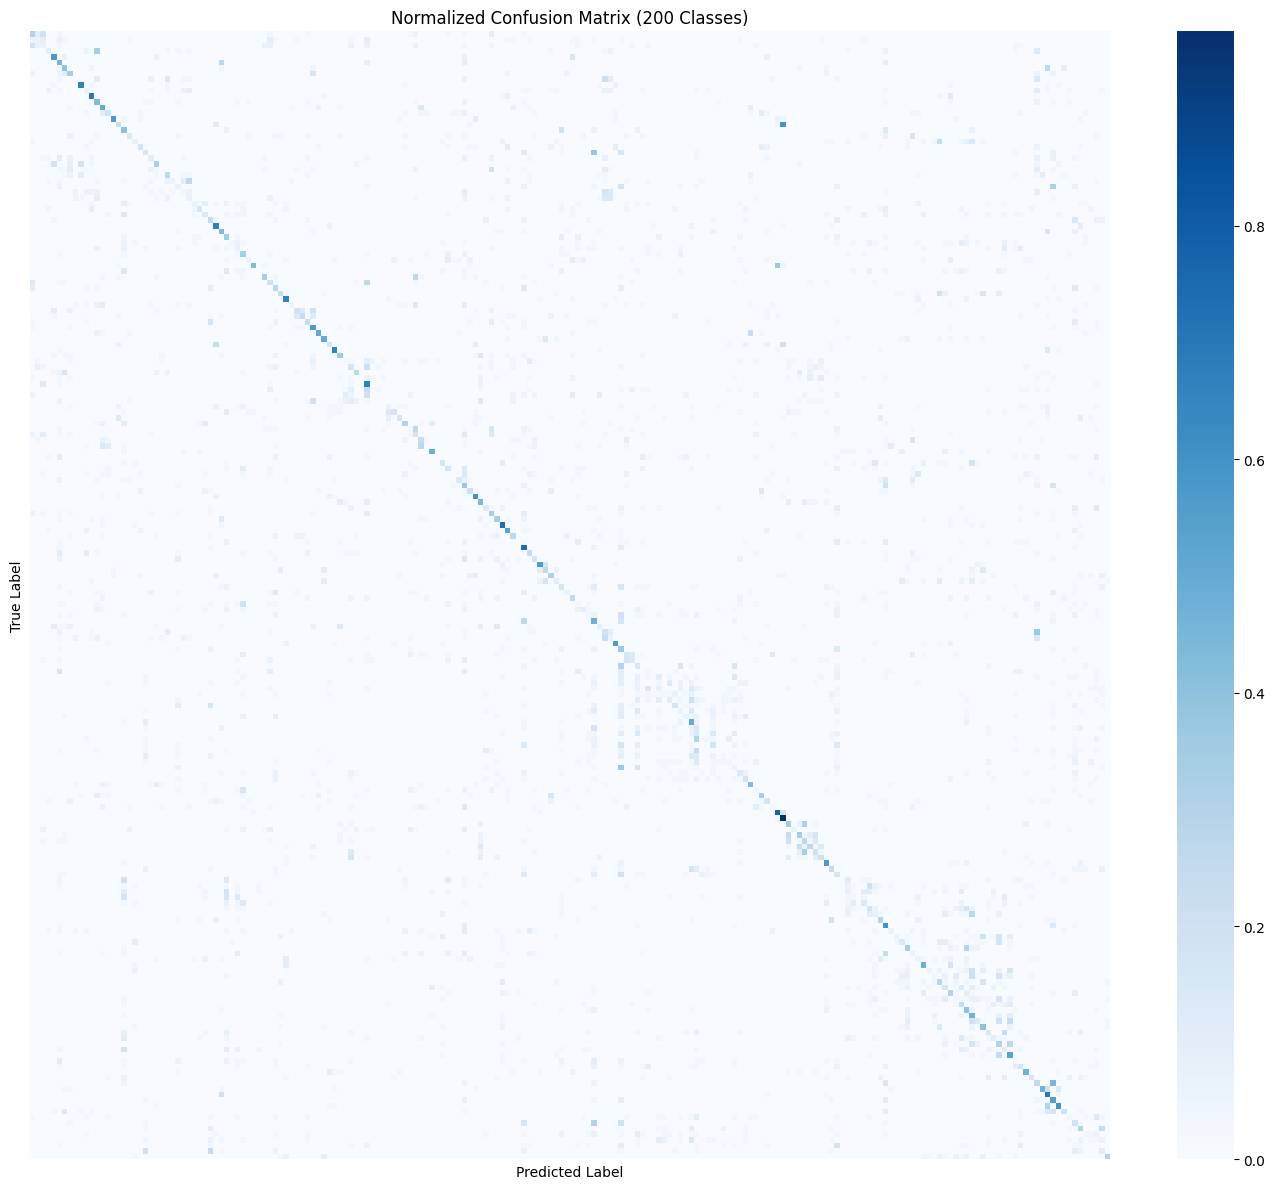

In [27]:
import seaborn as sns


# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Normalize by true class (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_normalized,
    cmap="Blues",       # clean professional colormap
    cbar=True,
    xticklabels=False,    # too many labels to display
    yticklabels=False
)

plt.title("Normalized Confusion Matrix (200 Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
custom_model.save(f"{project_path}/final_custom_model.keras")

# Extract unique class names from the 'image_name' column in 'df'
# The 'image_name' column format is '001.Class_Name/image.jpg'
# We extract 'Class_Name' and ensure the list is ordered by class_id.
unique_classes_info = df[['class_id', 'image_name']].drop_duplicates(subset=['class_id'])
unique_classes_info['extracted_class_name'] = unique_classes_info['image_name'].apply(lambda x: x.split('/')[0][4:])
sorted_classes = unique_classes_info.sort_values(by='class_id')
class_names = sorted_classes['extracted_class_name'].tolist()

np.save(f"{project_path}/class_names_custom.npy", class_names)







# Demo Function

In [ ]:
import zipfile
import os

def extract_zip(zip_path, extract_to="/content/new_test"):
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    return extract_to

In [ ]:
model_path = "/content/drive/MyDrive/DL_Coursework_Project/final_efficientnet_b4.keras"

efficient_model = tf.keras.models.load_model(model_path)

In [ ]:
import numpy as np

class_names = np.load(
    "/content/drive/MyDrive/DL_Coursework_Project/class_names.npy"
)

In [ ]:
import tensorflow as tf

def preprocess_demo_image_efficientnet(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # EfficientNet preprocessing
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image

In [ ]:
import os
import glob

def predict_folder_efficient(model, folder_path, class_names):

    image_paths = glob.glob(os.path.join(folder_path, "*.jpg"))
    #image_paths = glob.glob(os.path.join(folder_path, "**", "*.*"), recursive=True)

    results = []

    for img_path in image_paths:
        image = preprocess_demo_image_efficientnet(img_path)
        image = tf.expand_dims(image, axis=0)

        preds = model.predict(image, verbose=0)
        pred_class = np.argmax(preds, axis=1)[0]
        confidence = float(np.max(preds))

        results.append({
            "image": os.path.basename(img_path),
            "pred_index": pred_class,
            "predicted_class": class_names[pred_class],
            "confidence": confidence
        })

    return results

In [ ]:
zip_path = "/content/new_test.zip"

folder = extract_zip(zip_path)

predictions = predict_folder_efficient(
    efficient_model,
    folder,
    class_names
)

for p in predictions[:5]:
    print(p)

{'image': 'Brown_Thrasher_0120_155133.jpg', 'pred_index': np.int64(148), 'predicted_class': np.str_('Brown_Thrasher'), 'confidence': 0.9999839067459106}
{'image': 'Grasshopper_Sparrow_0051_115923.jpg', 'pred_index': np.int64(120), 'predicted_class': np.str_('Grasshopper_Sparrow'), 'confidence': 0.9932576417922974}
{'image': 'Tennessee_Warbler_0092_174810.jpg', 'pred_index': np.int64(178), 'predicted_class': np.str_('Tennessee_Warbler'), 'confidence': 0.6138729453086853}
{'image': 'Brewer_Blackbird_0010_2269.jpg', 'pred_index': np.int64(26), 'predicted_class': np.str_('Shiny_Cowbird'), 'confidence': 0.8649191856384277}
{'image': 'Yellow_Billed_Cuckoo_0074_26466.jpg', 'pred_index': np.int64(119), 'predicted_class': np.str_('Fox_Sparrow'), 'confidence': 0.8694961667060852}


In [ ]:
correct = 0

for p in predictions:
    img_name = p["image"]

    # Get original path
    original_path = [sp for sp in sample_paths if os.path.basename(sp) == img_name][0]

    true_label = test_df[test_df["filepath"] == original_path]["label"].values[0]

    if p["pred_index"] == true_label:
        correct += 1

accuracy = correct / len(predictions)

print("Demo Accuracy:", round(accuracy * 100, 2), "%")

Demo Accuracy: 80.0 %


In [ ]:
import matplotlib.pyplot as plt

def show_predictions(model, folder_path, class_names, num_images=5):

    image_paths = glob.glob(os.path.join(folder_path, "*.jpg"))[:num_images]

    for img_path in image_paths:
        image = preprocess_demo_image_efficientnet(img_path)
        image_batch = tf.expand_dims(image, axis=0)

        preds = model.predict(image_batch, verbose=0)
        pred_class = np.argmax(preds, axis=1)[0]
        confidence = np.max(preds)

        plt.imshow(tf.keras.preprocessing.image.load_img(img_path))
        plt.title(f"{class_names[pred_class]} ({confidence*100:.2f}%)")
        plt.axis("off")
        plt.show()

#Report

A fine-grained bird classification model was developed using the CUB-200-2011 dataset containing 200 visually similar bird species with bounding box annotations. The dataset was extracted in Colab and organized into train, validation and test splits. During preprocessing, images were cropped using bounding box coordinates to reduce background noise and resized to 380×380 pixels to match EfficientNet-B4 input resolution. EfficientNet-specific preprocessing was applied for the transfer learning model, while the custom CNN used normalization to [0,1]. Moderate augmentation (horizontal flipping, small rotations, zoom, brightness adjustments) improved generalization, whereas stronger augmentation distorted fine-grained features and reduced validation accuracy.

Initially, ResNet-50 was evaluated but did not achieve satisfactory validation performance despite augmentation tuning. The architecture was then switched to EfficientNet, comparing B3 and B4 variants. Given available GPU resources, EfficientNet-B4 was selected due to its higher resolution and representational capacity. A two-phase training strategy was used where first freezing the backbone (LR=1e-3), then partially unfreezing upper layers with a reduced learning rate (1e-4). Learning rate scheduling techniques were tested, including ReduceLROnPlateau and Cosine Decay, with cosine decay providing smoother convergence and slightly better validation results. Both GELU and ReLU activations were evaluated in the classification head. ReLU demonstrated more stable performance and was retained.

For Model 2, a custom CNN was designed from scratch. Two architectures (~4M and ~8M parameters) were tested. The smaller model underfit the data, indicating insufficient capacity to capture subtle inter-class differences. The 8M-parameter model showed improved learning and was selected. To reduce computational complexity and enable stable training, input resolution was reduced to 128×128. Custom preprocessing and dataset pipelines were implemented for consistency. Various augmentation strengths were tested and mild augmentation performed best as fine-grained classification depends on subtle visual details. Cosine learning rate decay and early stopping were used to stabilize training and prevent overfitting.

The final EfficientNet-B4 model achieved approximately 98% training accuracy, 84–85% validation accuracy, and 85.57% test accuracy, with strong diagonal dominance in the normalized confusion matrix. Macro precision, recall and F1-score confirmed balanced performance across classes. The custom CNN achieved 32.72% test accuracy, highlighting the importance of pretrained feature extractors for fine-grained visual recognition tasks. Overall, transfer learning significantly outperformed training from scratch, demonstrating the effectiveness of pretrained representations in limited-data scenarios.